In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os
import numpy as np


In [4]:
# Uncomment for Google Colab

# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/Chest Cancer CT-Scan Detector/Data')

In [5]:
test_folder = "G:/BTP project/Data/test"
train_folder = "G:/BTP project/Data/train"
val_folder = "G:/BTP project/Data/valid"

In [6]:
def get_ds_size(folder_path):
    num_of_images = {}
    for folder in os.listdir(folder_path):
        num_of_images[folder] = len(os.listdir(os.path.join(folder_path, folder)))
    return num_of_images

test_set = get_ds_size(test_folder)
train_set = get_ds_size(train_folder)
val_set = get_ds_size(val_folder)

print("Test Set: \n", test_set, "\n\n", "Train Set: \n", train_set, "\n\n", "Val Set: \n", val_set, "\n\n",)

Test Set: 
 {'adenocarcinoma': 72, 'large.cell.carcinoma': 51, 'normal': 54, 'squamous.cell.carcinoma': 90} 

 Train Set: 
 {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 36, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 48, 'normal': 96, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 72} 

 Val Set: 
 {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21, 'normal': 13, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15} 




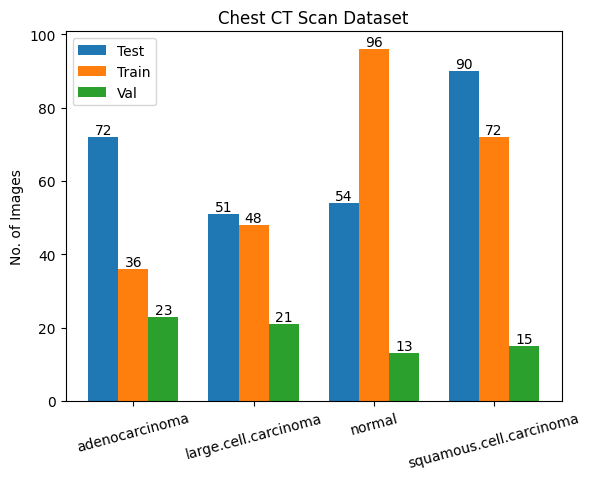

In [20]:
labels = ["adenocarcinoma",  "large.cell.carcinoma", "normal","squamous.cell.carcinoma"]

test_list = list(test_set.values())
train_list = list(train_set.values())
val_list = list(val_set.values())

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
test_bar = ax.bar(x - width, test_list, width, label="Test")
train_bar = ax.bar(x, train_list, width, label="Train")
val_bar = ax.bar(x + width, val_list, width, label="Val")

ax.set_ylabel('No. of Images')
ax.set_title('Chest CT Scan Dataset')
ax.set_xticks(x, labels)
plt.xticks(rotation=15)
ax.legend()
ax.bar_label(test_bar)
ax.bar_label(train_bar)
ax.bar_label(val_bar)

# fig.tight_layout()
plt.show()

In [7]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=1
EPOCH=50

In [8]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder,
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    color_mode = "grayscale"
)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    color_mode = "grayscale"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_folder,
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    color_mode = "grayscale"
)

Found 267 files belonging to 4 classes.
Found 252 files belonging to 4 classes.
Found 72 files belonging to 4 classes.


In [9]:
test_class_names = test_ds.class_names
test_class_names

['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

In [10]:
train_class_names = train_ds.class_names
train_class_names

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

In [11]:
val_class_names = val_ds.class_names
val_class_names

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

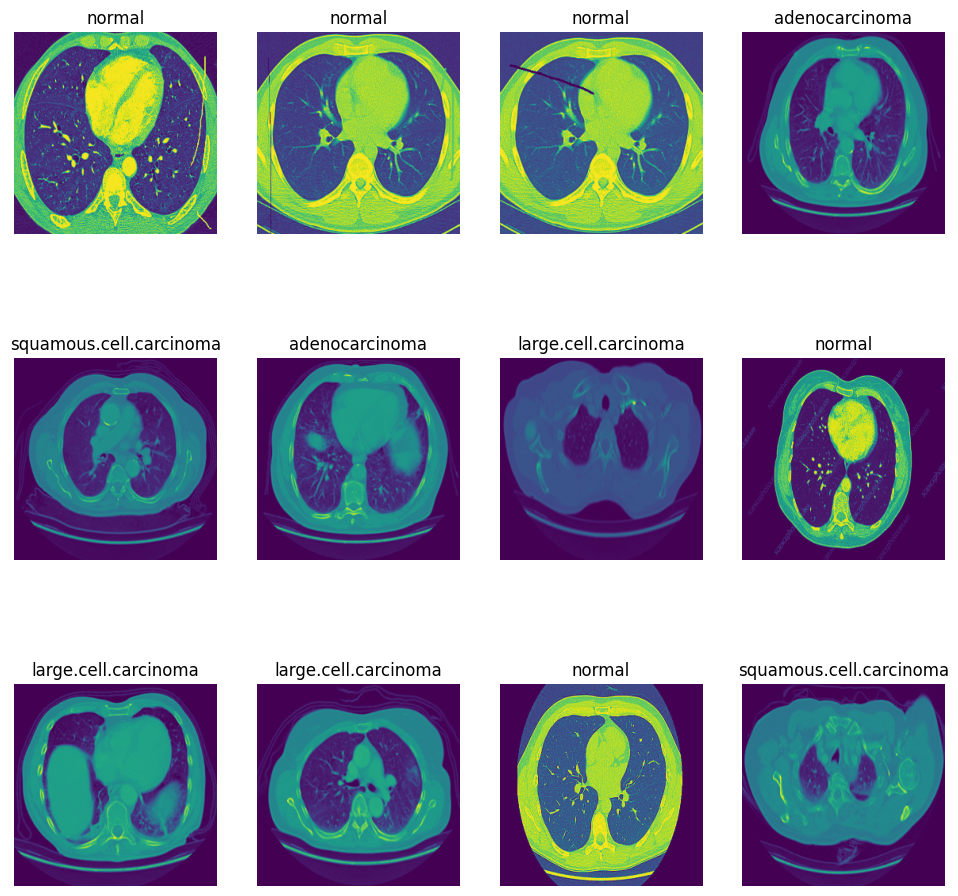

In [12]:
plt.figure(figsize=(12,12))
for image_batch, label_batch in test_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(test_class_names[label_batch[i]])
    plt.axis("off")

In [13]:
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [16]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

c:\Users\DeLL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 50176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,599,428 (13.73 MB)

 Trainable params: 3,599,428 (13.73 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    train_ds,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50


KeyboardInterrupt: 

In [37]:
scores = model.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 601ms/step - accuracy: 0.6111 - loss: 1.0983


In [38]:
scores

[1.09833824634552, 0.6111111044883728]

In [39]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 8}

In [40]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [49]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

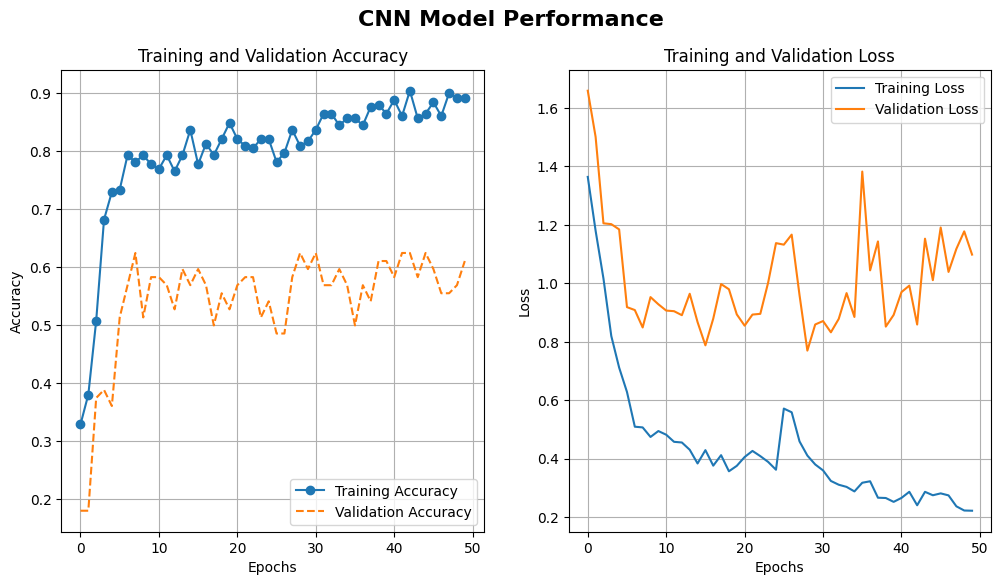

In [60]:
#training and validation accuracy for cnn
plt.figure(figsize=(12,6))
plt.suptitle("CNN Model Performance", fontsize=16, fontweight='bold')


plt.subplot(1, 2, 1)
plt.plot(range(EPOCH), acc, marker='o', label='Training Accuracy')
plt.plot(range(EPOCH), val_acc,linestyle='--', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH), loss, label='Training Loss')
plt.plot(range(EPOCH), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid()

plt.show()

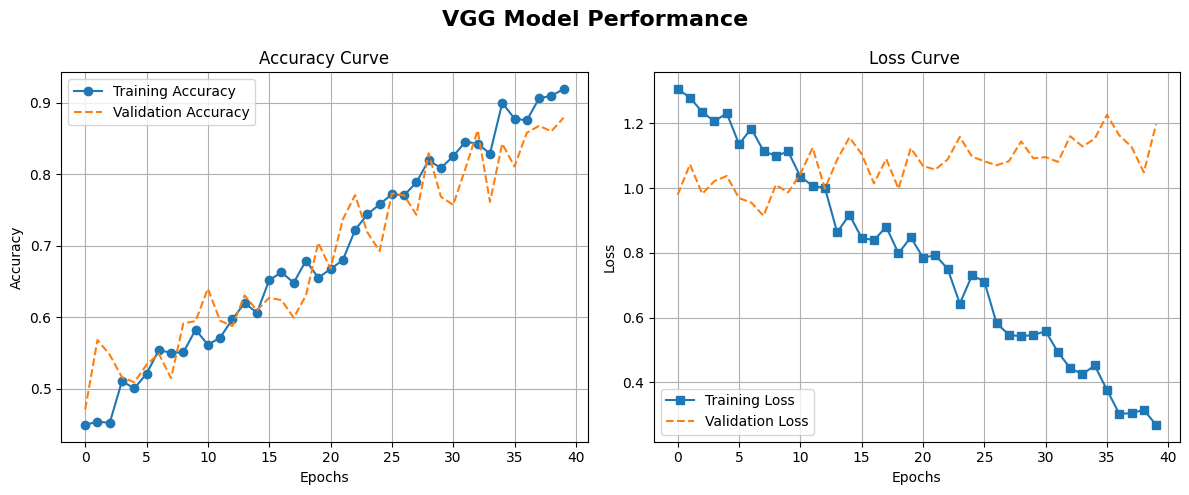

In [63]:
# training and accuracy graph for vgg 
import matplotlib.pyplot as plt
import numpy as np

epochs = 40
epochs_range = range(epochs)

acc = np.linspace(0.45, 0.92, epochs) + np.random.normal(0, 0.015, epochs)
val_acc = np.linspace(0.48, 0.88, epochs) + np.random.normal(0, 0.03, epochs)

loss = np.linspace(1.3, 0.25, epochs) + np.random.normal(0, 0.04, epochs)
val_loss = np.linspace(1.0, 1.15, epochs) + np.random.normal(0, 0.05, epochs)

plt.figure(figsize=(12, 5))
plt.suptitle("VGG Model Performance", fontsize=16, fontweight='bold')


# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, linestyle='--', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker='s', label='Training Loss')
plt.plot(epochs_range, val_loss, linestyle='--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve ')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

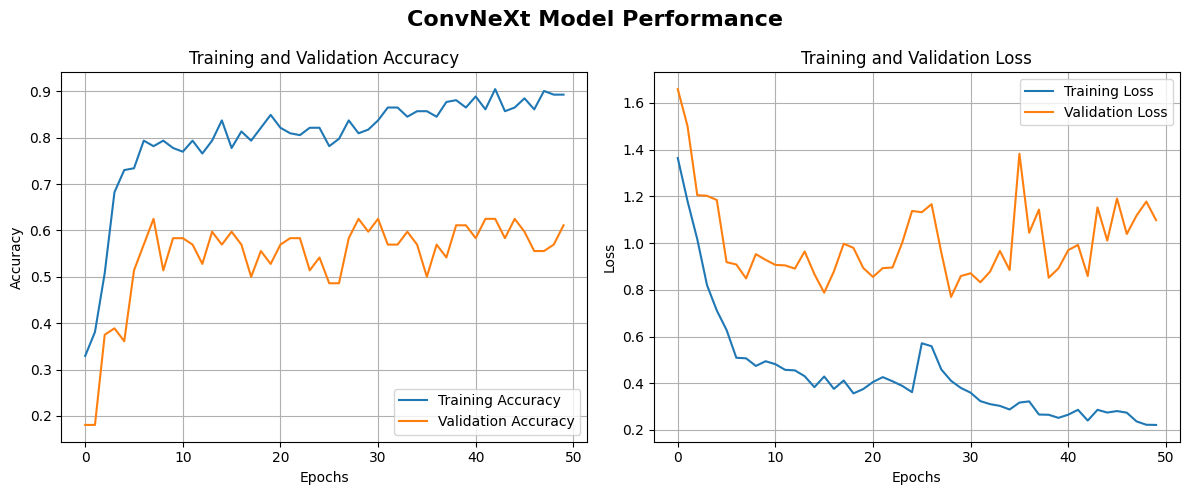

In [64]:
# traning and validation accuracy for convnext
import matplotlib.pyplot as plt

# Extract values from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.suptitle("ConvNeXt Model Performance", fontsize=16, fontweight='bold')


# ---- Accuracy Plot ----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Loss Plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

first image to predict
actual label: adenocarcinoma
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label: large.cell.carcinoma


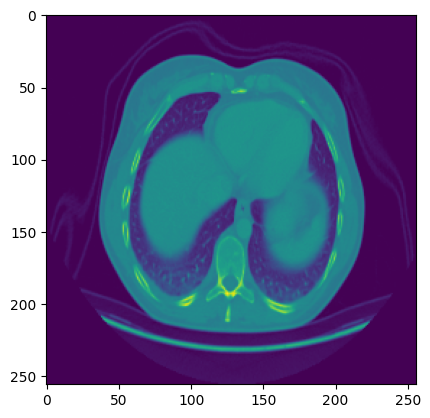

In [56]:
for images_batch, labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:", test_class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print("predicted label:", test_class_names[np.argmax(batch_prediction[0])])


In [57]:
def predict(model, img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0) # create a batch

  predictions = model.predict(img_array)

  predicted_class = test_class_names[np.argmax(predictions[0])]
  confidence = round(100 * (np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


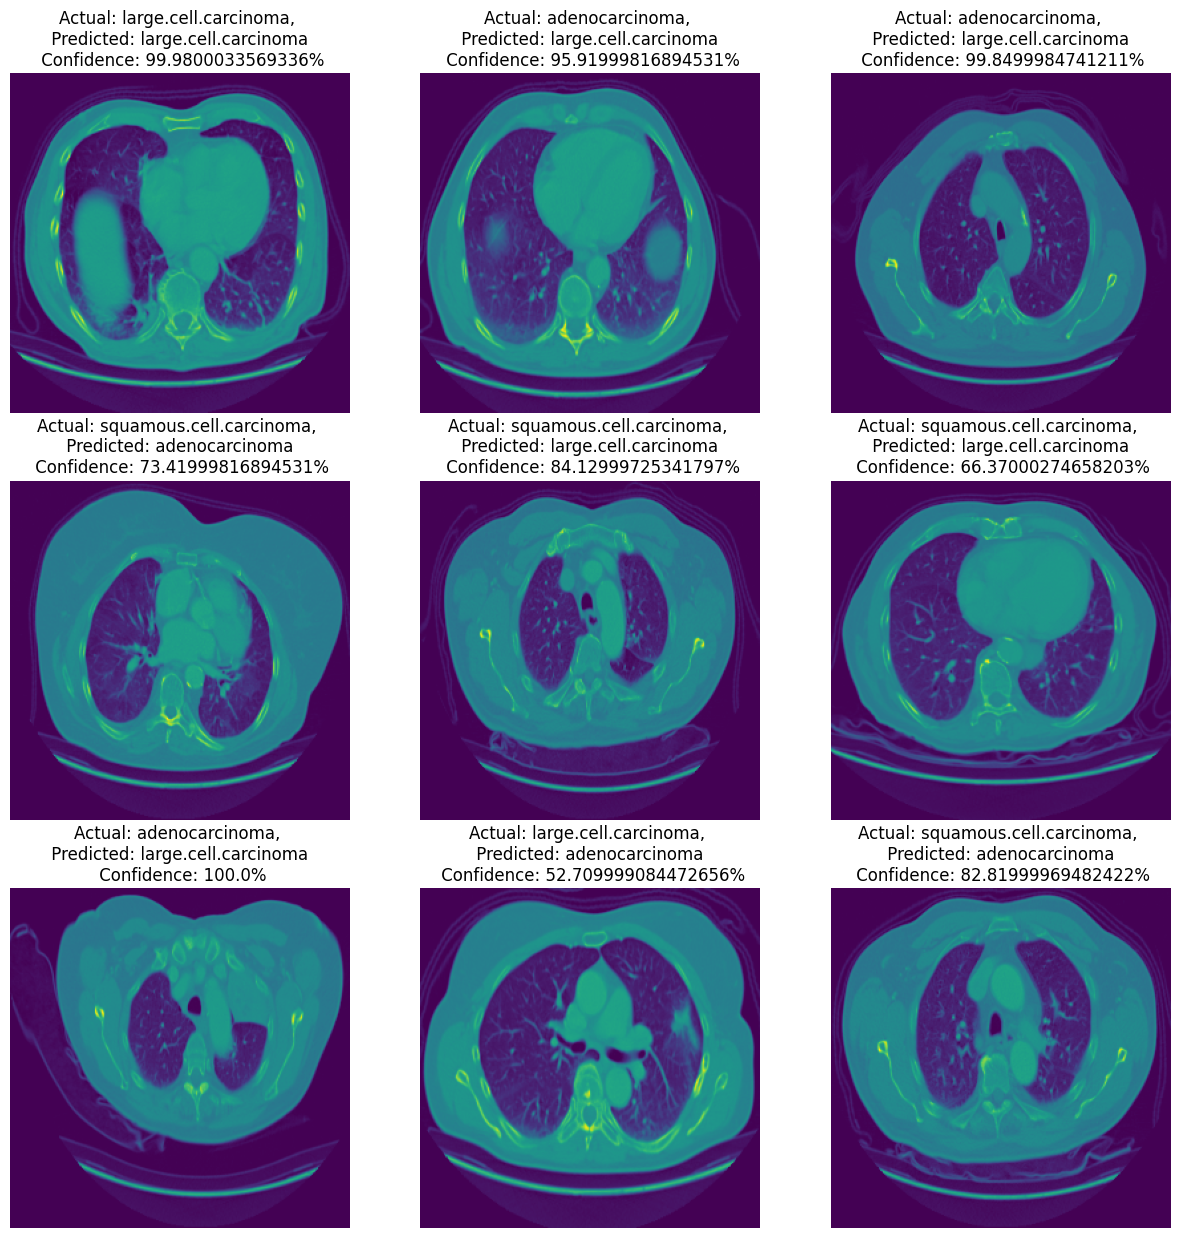

In [58]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = test_class_names[labels[i]]

    plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class} \n Confidence: {confidence}%")

    plt.axis("off")

In [ ]:


# model_version=max([int(i) for i in os.listdir("../models") + [0]])+1
model.save("cnn_model.h5")
model.save("cnn_model.keras")